# 02 · Numerical Scheme (FTCS)

## Discretization

Grid: `xᵢ = iΔx`, `i = 0..N`, `Δx = L/N`.  
Time: `tⁿ = nΔt`.

Forward-time / centered-space:

    (u_i^{n+1} - u_i^n)/Δt  =  α (u_{i+1}^n - 2u_i^n + u_{i-1}^n)/Δx²

Rearranged:

    u_i^{n+1} = u_i^n + r (u_{i+1}^n - 2u_i^n + u_{i-1}^n),
    r = α Δt / Δx²

Boundary (Dirichlet):  `u_0^n = u_N^n = 0` for all n.

## Stability (Von Neumann)

Amplification factor for a mode `e^{iθi}`:

    G(θ) = 1 - 4r sin²(θ/2)

Stability requires `|G(θ)| ≤ 1 ∀ θ`, giving the condition

    r ≤ 1/2.

In [ ]:
# Cell 2 — Imports & parameters
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from src.heat_equation import (
    analytical_solution,
    ftcs_solver,
    initial_condition_sine,
    initial_condition_step,
)
from src.utils import linf_error, l2_error

L     = 1.0
alpha = 0.01
Nx    = 101
x     = np.linspace(0.0, L, Nx)
dx    = x[1] - x[0]

r     = 0.4                    # stable
dt    = r * dx**2 / alpha
T     = 0.1
n_steps = int(round(T / dt))
dt      = T / n_steps          # adjust to land exactly on T

print(f"Nx = {Nx}, Δx = {dx:.4f}, r = {r}, Δt = {dt:.3e}, steps = {n_steps}")

Nx = 101, Δx = 0.0100, r = 0.4, Δt = 4.000e-03, steps = 25


## 1. FTCS on a single-mode IC

Because mode 1 is an exact eigenfunction of the continuous problem and the
scheme is exact on it (in space), the numerical solution should track the
analytical decay closely.

L∞ error = 1.125e-06
L2 error = 7.958e-07


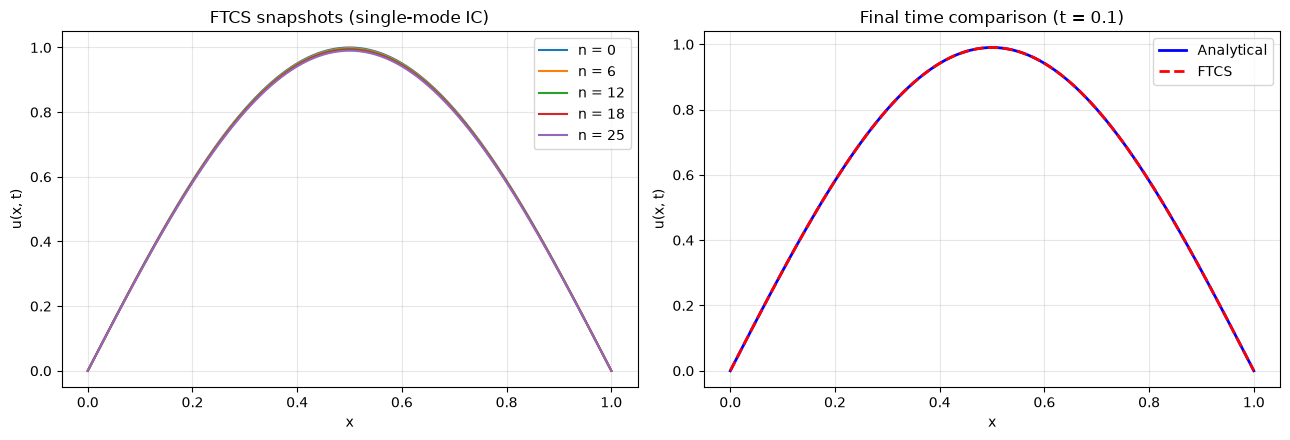

In [2]:
# Cell 4 — Single-mode FTCS vs analytical
u0 = initial_condition_sine(x, L)

hist   = ftcs_solver(u0, alpha, dx, dt, n_steps)
u_num  = hist[-1]
u_exact = analytical_solution(x, T, alpha, L, u0, n_modes=50)

print(f"L∞ error = {linf_error(u_num, u_exact):.3e}")
print(f"L2 error = {l2_error(u_num, u_exact, dx):.3e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Snapshots
snap_idx = np.linspace(0, n_steps, 5, dtype=int)
for k in snap_idx:
    axes[0].plot(x, hist[k], label=f"n = {k}")
axes[0].set_xlabel("x"); axes[0].set_ylabel("u(x, t)")
axes[0].set_title("FTCS snapshots (single-mode IC)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Final comparison
axes[1].plot(x, u_exact, "b-",  lw=2, label="Analytical")
axes[1].plot(x, u_num,   "r--", lw=2, label="FTCS")
axes[1].set_xlabel("x"); axes[1].set_ylabel("u(x, t)")
axes[1].set_title(f"Final time comparison (t = {T})")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 2. Error as a function of x at the final time

Plot `u_num − u_exact` to see the spatial structure of the numerical error.

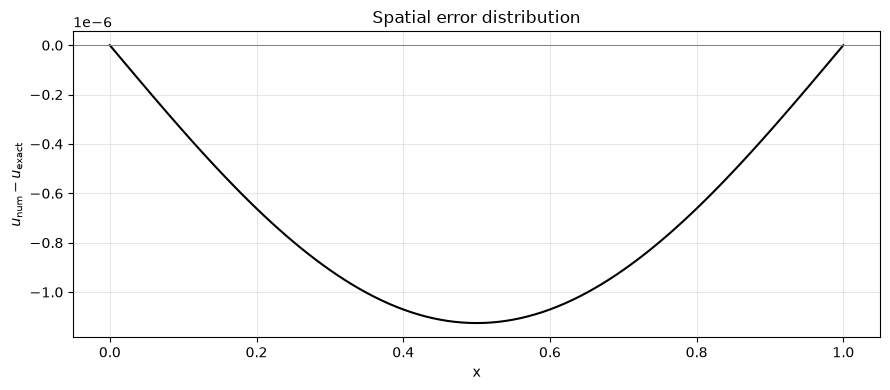

In [3]:
# Cell 6 — Spatial error field
err = u_num - u_exact

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, err, "k-")
ax.axhline(0, color="gray", lw=0.7)
ax.set_xlabel("x"); ax.set_ylabel(r"$u_\mathrm{num} - u_\mathrm{exact}$")
ax.set_title("Spatial error distribution")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Stability behavior

We run FTCS with several `r` values and track `max|u|` over time.  
Theory predicts:
- `r ≤ 1/2` → bounded (stable)
- `r > 1/2` → oscillations grow exponentially (unstable)

FTCS is unstable for r = 0.510 > 0.5. Reduce dt or increase dx.
FTCS is unstable for r = 0.600 > 0.5. Reduce dt or increase dx.


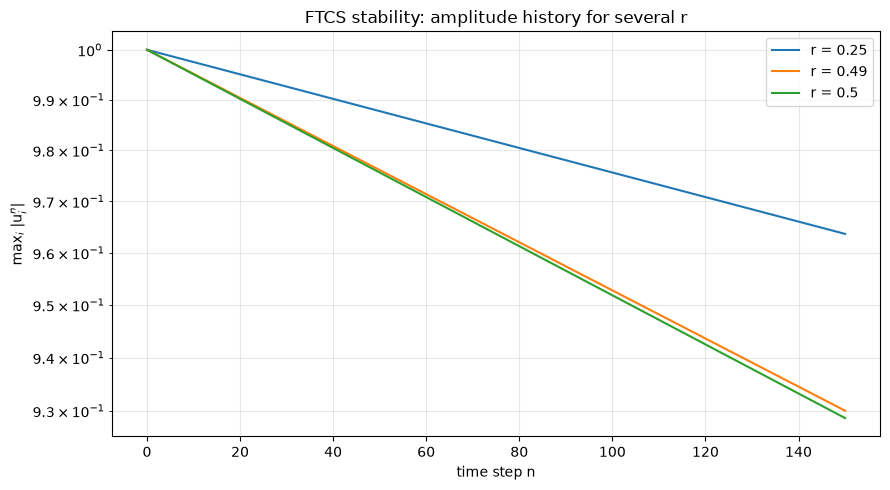

In [4]:
# Cell 8 — Stability sweep (time traces)
r_values = [0.25, 0.49, 0.5, 0.51, 0.6]
n_steps_sweep = 150

fig, ax = plt.subplots(figsize=(9, 5))
for r_val in r_values:
    dt_r = r_val * dx**2 / alpha
    try:
        hist_r = ftcs_solver(u0, alpha, dx, dt_r, n_steps_sweep)
        amp    = np.max(np.abs(hist_r[:, 1:-1]), axis=1)
        style  = "-" if r_val <= 0.5 else "--"
        ax.semilogy(amp, style, label=f"r = {r_val}")
    except ValueError as e:
        print(e)

ax.set_xlabel("time step n"); ax.set_ylabel(r"max$_i$ |u$_i^n$|")
ax.set_title("FTCS stability: amplitude history for several r")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## 4. Numerical amplification factor

For a single Fourier mode `e^{iθi}`, the scheme gives

    G(θ) = 1 - 4r sin²(θ/2)

Plot `|G(θ)|` for various `r` and observe the threshold at `r = 1/2`.

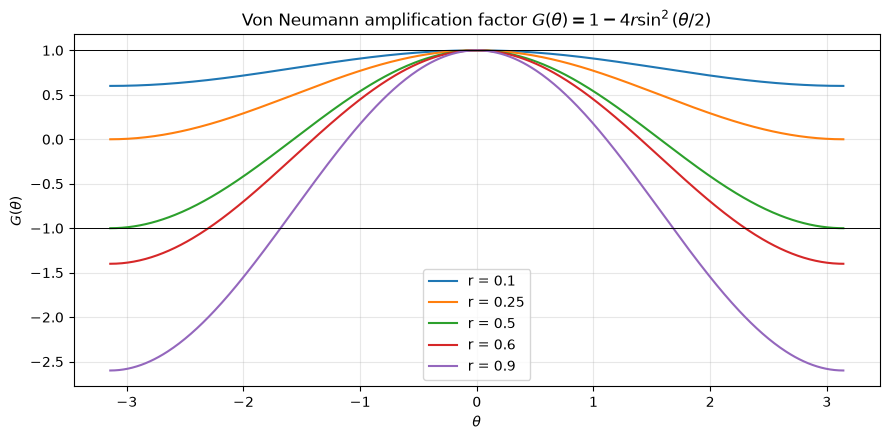

In [5]:
# Cell 10 — |G(θ)| for several r
theta = np.linspace(-np.pi, np.pi, 500)

fig, ax = plt.subplots(figsize=(9, 4.5))
for r_val in [0.1, 0.25, 0.5, 0.6, 0.9]:
    G = 1 - 4*r_val*np.sin(theta/2)**2
    ax.plot(theta, G, label=f"r = {r_val}")
ax.axhline( 1, color="k", lw=0.7)
ax.axhline(-1, color="k", lw=0.7)
ax.set_xlabel(r"$\theta$"); ax.set_ylabel(r"$G(\theta)$")
ax.set_title(r"Von Neumann amplification factor $G(\theta) = 1 - 4r\sin^2(\theta/2)$")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Second IC: square pulse

The square pulse is harder because the Fourier series has slow decay. We
expect the numerical and analytical results to agree well after the initial
transient (which is smoothed immediately).

L∞ error = 3.358e-03


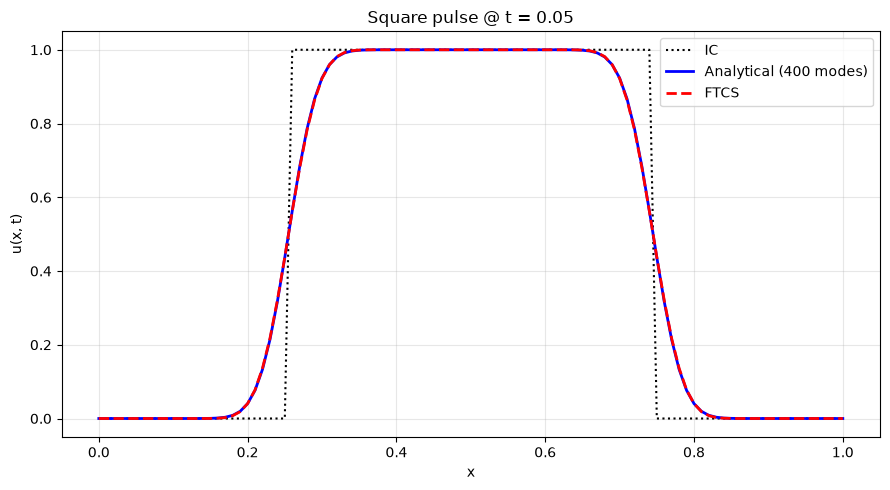

In [6]:
# Cell 12 — Square-pulse IC comparison
u0_step = initial_condition_step(x, L, height=1.0)

T_step   = 0.05
n_steps_s = int(round(T_step / dt))
dt_s      = T_step / n_steps_s

hist_s = ftcs_solver(u0_step, alpha, dx, dt_s, n_steps_s)
u_num_s = hist_s[-1]
u_ex_s  = analytical_solution(x, T_step, alpha, L, u0_step, n_modes=400)

print(f"L∞ error = {linf_error(u_num_s, u_ex_s):.3e}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, u0_step, "k:",  lw=1.5, label="IC")
ax.plot(x, u_ex_s,  "b-",  lw=2,   label="Analytical (400 modes)")
ax.plot(x, u_num_s, "r--", lw=2,   label="FTCS")
ax.set_xlabel("x"); ax.set_ylabel("u(x, t)")
ax.set_title(f"Square pulse @ t = {T_step}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Energy / L2-norm decay

For Dirichlet BCs, the L2 norm decays monotonically. We check that the
numerical scheme preserves this property.

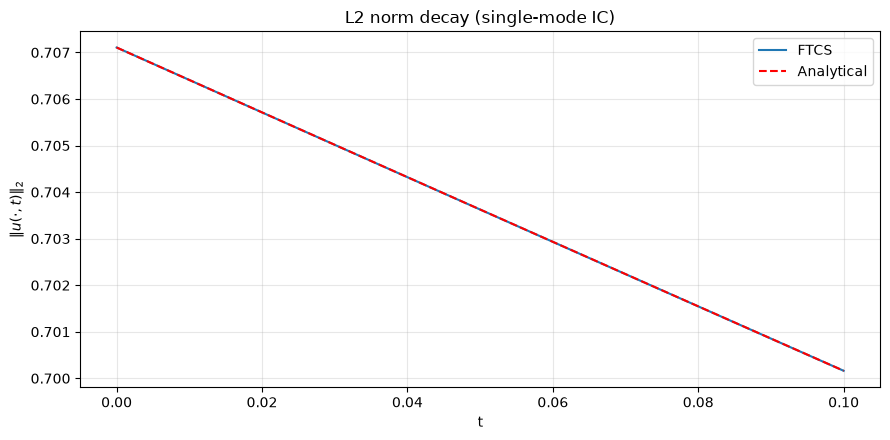

In [7]:
# Cell 14 — L2 norm history (numerical vs analytical)
l2_hist_num = np.sqrt(dx * np.sum(hist**2, axis=1))
t_hist      = np.arange(n_steps + 1) * dt

l2_hist_ana = np.array([
    np.sqrt(dx * np.sum(
        analytical_solution(x, t, alpha, L, u0, n_modes=50)**2
    ))
    for t in t_hist
])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_hist, l2_hist_num, "C0-",  label="FTCS")
ax.plot(t_hist, l2_hist_ana, "r--",  label="Analytical")
ax.set_xlabel("t"); ax.set_ylabel(r"$\|u(\cdot,t)\|_2$")
ax.set_title("L2 norm decay (single-mode IC)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## ✅ Summary
- FTCS is second-order accurate in space, first-order in time.
- Stability requires `r = α Δt / Δx² ≤ 1/2`.
- Matches analytical solution closely when stable; blows up when unstable.

**Next:** `03_error_and_convergence.ipynb` — grid refinement & orders of accuracy.